##### Imports:

In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Load matched dataset
df = pd.read_parquet("Outputs/lr_epc_matched.parquet")

# Load postcode directory — only columns we need
postcodes = pd.read_csv(
    "Data/Online_ONS_Postcode_Directory_Live.csv",
    usecols=["PCDS", "LAT", "LONG"]
)

# Normalise postcode format for merging
df["postcode_merge"] = df["postcode_x"].str.strip().str.upper()
postcodes["PCDS"] = postcodes["PCDS"].str.strip().str.upper()

# Merge
df = df.merge(postcodes, left_on="postcode_merge", right_on="PCDS", how="left")

# Check coverage
matched_geo = df["LAT"].notna().sum()
print(f"Properties with lat/lon: {matched_geo:,} ({matched_geo/len(df)*100:.1f}%)")
print(f"Missing lat/lon:         {df['LAT'].isna().sum():,}")

df.head(2)

Properties with lat/lon: 5,866,936 (99.6%)
Missing lat/lon:         23,153


,transaction_id,price,date,postcode_x,property_type_x,new_build,duration,paon,saon,street,...,property_type_y,transaction_type,construction_age_band,built_form,main_fuel,mains_gas_flag,postcode_merge,PCDS,LAT,LONG
0,{01EB45EF-612C-40F3-E063-4704A8C05FDE},1281150,2023-06-16,N7 7BG,T,N,F,31,NaN,BRYANTWOOD ROAD,...,House,Marketed sale,England and Wales: 1900-1929,Mid-Terrace,mains gas (not community),Y,N7 7BG,N7 7BG,51.55244,-0.107227
1,{01EB45EF-612D-40F3-E063-4704A8C05FDE},1675000,2023-06-23,SE22 8UG,T,N,F,33,NaN,BEAUVAL ROAD,...,House,Marketed sale,England and Wales: before 1900,Mid-Terrace,mains gas (not community),Y,SE22 8UG,SE22 8UG,51.45220,-0.078014


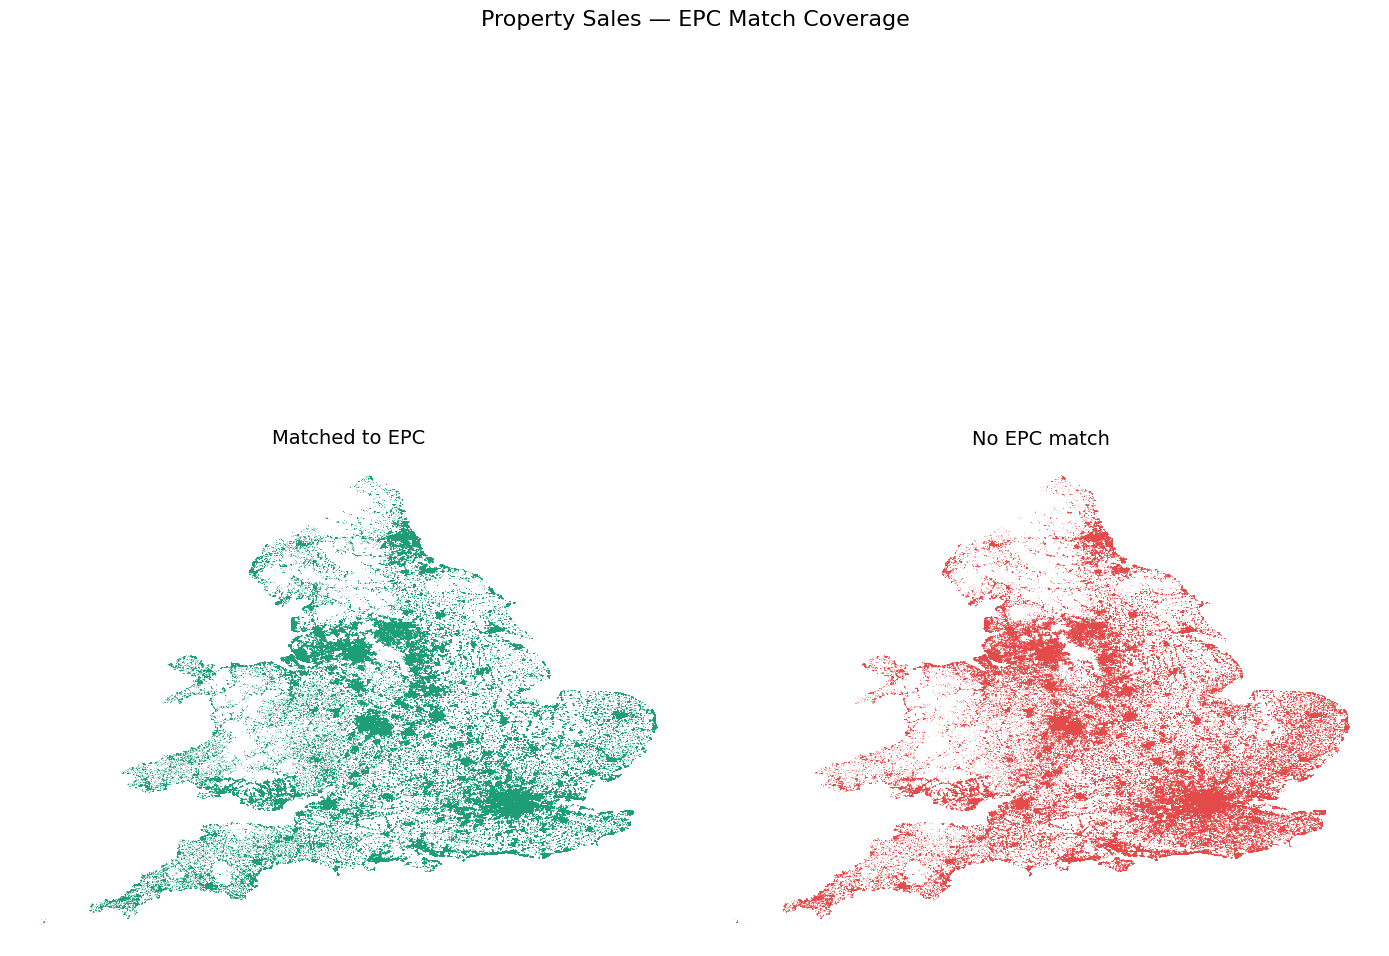

In [ ]:
# Load
df = pd.read_parquet("Outputs/lr_epc_matched.parquet")
postcodes = pd.read_csv(
    "Data/Online_ONS_Postcode_Directory_Live.csv",
    usecols=["PCDS", "LAT", "LONG"]
)
postcodes["PCDS"] = postcodes["PCDS"].str.strip().str.upper()
df["postcode_merge"] = df["postcode_x"].str.strip().str.upper()
df = df.merge(postcodes, left_on="postcode_merge", right_on="PCDS", how="left")

# Clean
df = df[df["LAT"].notna() & (df["LAT"] != 99.999999)]
df["has_epc"] = df["lodgement_date"].notna()

# Sample
matched   = df[df["has_epc"]]
unmatched = df[~df["has_epc"]]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 16), sharey=True)

for ax, data, color, title in [
    (axes[0], matched,   "#1D9E75", "Matched to EPC"),
    (axes[1], unmatched, "#E24B4A", "No EPC match"),
]:
    ax.scatter(data["LONG"], data["LAT"], s=0.3, alpha=0.3, color=color, linewidths=0)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.axis("off")

axes[0].set_ylabel("Latitude")
fig.suptitle("Property Sales — EPC Match Coverage", fontsize=16, y=0.92)
plt.tight_layout()
#plt.savefig("epc_coverage_map.png", dpi=150, bbox_inches="tight") Good idea to save for write up.
plt.show()

# Schools

In [ ]:
df_schools = pd.read_parquet("Outputs/lr_epc_schools.parquet")

for col, label in [("dist_primary_km", "Primary"), ("dist_secondary_km", "Secondary")]:
    print(f"\n{label} school distance (km):")
    print(f"  Mean:   {df_schools[col].mean():.2f}")
    print(f"  Median: {df_schools[col].median():.2f}")
    print(f"  Max:    {df_schools[col].max():.2f}")
    print(f"  < 1km:  {(df_schools[col] < 1).sum():,} ({(df_schools[col] < 1).mean()*100:.1f}%)")
    print(f"  < 5km:  {(df_schools[col] < 5).sum():,} ({(df_schools[col] < 5).mean()*100:.1f}%)")


Primary school distance (km):
  Mean:   0.57
  Median: 0.45
  Max:    51.13
  < 1km:  5,267,919 (89.4%)
  < 5km:  5,858,420 (99.5%)

Secondary school distance (km):
  Mean:   1.73
  Median: 1.13
  Max:    53.47
  < 1km:  2,512,105 (42.6%)
  < 5km:  5,491,937 (93.2%)


In [14]:
pd.set_option("display.max_columns", None)
df_schools.head()

,transaction_id,price,date,postcode_x,property_type_x,new_build,duration,paon,saon,street,locality,town,district,county,ppd_category,record_status,postcode_clean,address_key,address1,postcode_y,uprn,total_floor_area,lodgement_date,current_energy_efficiency,current_energy_rating,number_habitable_rooms,tenure,property_type_y,transaction_type,construction_age_band,built_form,main_fuel,mains_gas_flag,postcode_merge,PCDS,LAT,LONG,exact_lat,exact_lon,has_exact_coords,dist_primary_km,dist_secondary_km
0,{01EB45EF-612C-40F3-E063-4704A8C05FDE},1281150,2023-06-16,N7 7BG,T,N,F,31,NaN,BRYANTWOOD ROAD,NaN,LONDON,ISLINGTON,GREATER LONDON,A,A,N77BG,31 BRYANTWOOD ROAD,31 Bryantwood Road,N7 7BG,5.300012e+09,164.0,2023-01-06,65.0,D,7.0,owner-occupied,House,Marketed sale,England and Wales: 1900-1929,Mid-Terrace,mains gas (not community),Y,N7 7BG,N7 7BG,51.55244,-0.107227,51.552537,-0.107757,True,0.177971,0.431792
1,{01EB45EF-612D-40F3-E063-4704A8C05FDE},1675000,2023-06-23,SE22 8UG,T,N,F,33,NaN,BEAUVAL ROAD,NaN,LONDON,SOUTHWARK,GREATER LONDON,A,A,SE228UG,33 BEAUVAL ROAD,33 Beauval Road,SE22 8UG,2.000034e+11,185.0,2023-02-01,60.0,D,6.0,owner-occupied,House,Marketed sale,England and Wales: before 1900,Mid-Terrace,mains gas (not community),Y,SE22 8UG,SE22 8UG,51.45220,-0.078014,51.452162,-0.078001,True,0.314241,0.805885
2,{01EB45EF-612E-40F3-E063-4704A8C05FDE},1255000,2023-01-27,NW5 3QE,T,N,F,12A,NaN,MODBURY GARDENS,NaN,LONDON,CAMDEN,GREATER LONDON,A,A,NW53QE,12A MODBURY GARDENS,12a Modbury Gardens,NW5 3QE,5.094465e+06,63.0,2022-12-13,72.0,C,2.0,owner-occupied,Flat,Marketed sale,England and Wales: 1900-1929,Mid-Terrace,mains gas (not community),Y,NW5 3QE,NW5 3QE,51.54692,-0.155168,51.546917,-0.155168,True,0.328799,0.267644
3,{01EB45EF-612F-40F3-E063-4704A8C05FDE},1855000,2023-06-30,N1 1HA,T,N,F,68,NaN,BROOKSBY STREET,NaN,LONDON,ISLINGTON,GREATER LONDON,A,A,N11HA,68 BROOKSBY STREET,"68, Brooksby Street",N1 1HA,5.300012e+09,134.0,2015-07-08,57.0,D,7.0,rented (private),House,Rental,England and Wales: before 1900,End-Terrace,mains gas (not community),Y,N1 1HA,N1 1HA,51.54197,-0.108124,51.541842,-0.109239,True,0.120810,1.016696
4,{01EB45EF-6130-40F3-E063-4704A8C05FDE},690000,2023-06-28,SE18 3NR,T,N,F,20,NaN,EGLINTON HILL,NaN,LONDON,GREENWICH,GREATER LONDON,A,A,SE183NR,20 EGLINTON HILL,20 Eglinton Hill,SE18 3NR,1.000210e+11,135.0,2022-09-22,66.0,D,5.0,owner-occupied,House,Marketed sale,England and Wales: 1900-1929,Mid-Terrace,mains gas (not community),Y,SE18 3NR,SE18 3NR,51.47663,0.068562,51.477433,0.068786,True,0.315211,1.241457


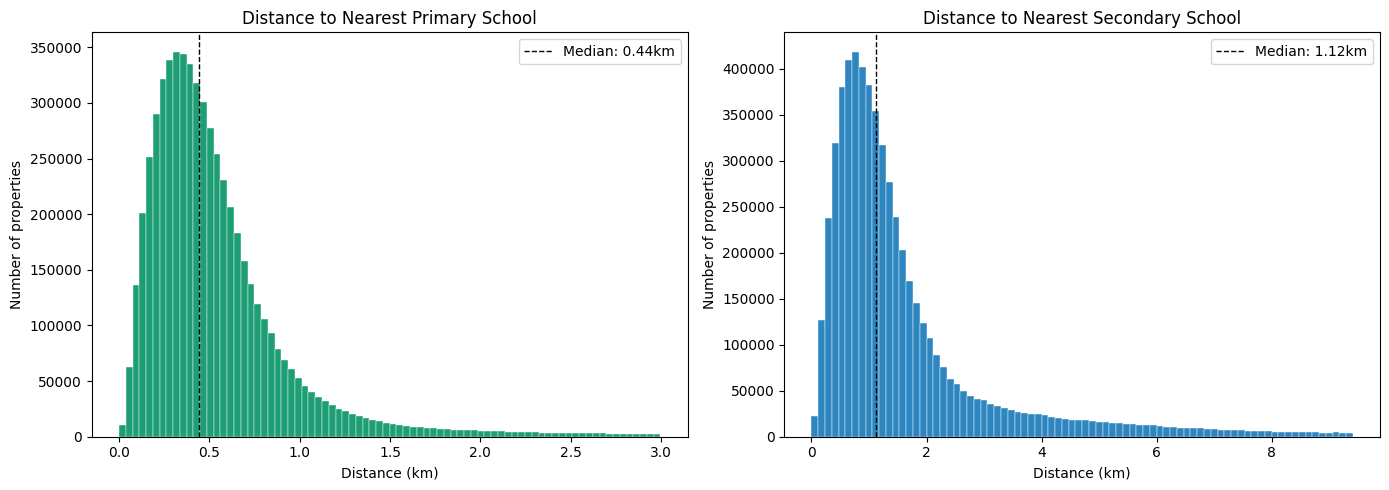

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, title in [
    (axes[0], "dist_primary_km",   "#1D9E75", "Distance to Nearest Primary School"),
    (axes[1], "dist_secondary_km", "#2E86C1", "Distance to Nearest Secondary School"),
]:
    data = df_schools[col].dropna()
    data = data[data < data.quantile(0.99)]  # trim top 1% for cleaner plot
    ax.hist(data, bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Number of properties")
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1, label=f"Median: {data.median():.2f}km")
    ax.legend()

plt.tight_layout()
plt.show()

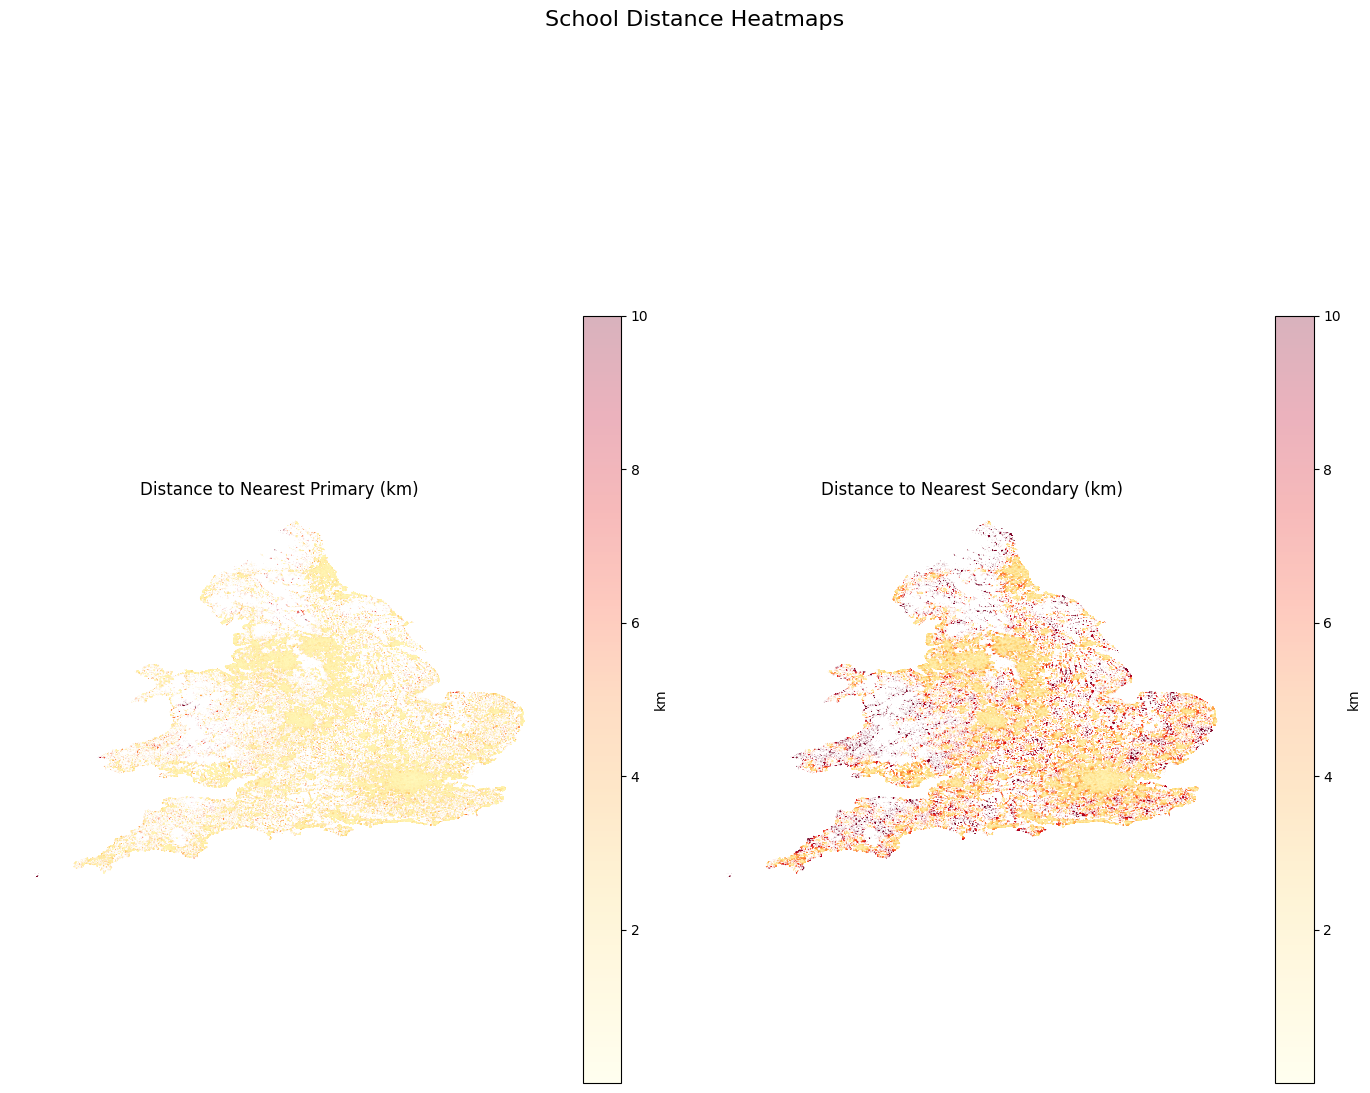

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 16), sharey=True)

lat = df_schools["exact_lat"].fillna(df_schools["LAT"])
lon = df_schools["exact_lon"].fillna(df_schools["LONG"])
mask = lat.notna() & lon.notna()

for ax, col, title, cmap in [
    (axes[0], "dist_primary_km",   "Distance to Nearest Primary (km)",   "YlOrRd"),
    (axes[1], "dist_secondary_km", "Distance to Nearest Secondary (km)", "YlOrRd"),
]:
    vals = df_schools.loc[mask, col].clip(upper=10)  # cap at 10km for colour scale
    sc = ax.scatter(
        lon[mask], lat[mask],
        c=vals, cmap=cmap,
        s=0.1, alpha=0.3, linewidths=0
    )
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(sc, ax=ax, shrink=0.5, label="km")

fig.suptitle("School Distance Heatmaps", fontsize=16, y=0.92)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure all postcodes match so I can remove rest and leave one. 
match = (df["postcode_x"].str.strip().str.upper().str.replace(" ", "") == 
         df["postcode_clean"].str.strip().str.upper().str.replace(" ", ""))
print(f"Same after removing spaces: {match.sum():,} ->  {len(df):,}")
print(f"Different: {(~match).sum():,}")

Same after removing spaces: 5,866,936 ->  5,866,936
Different: 0


## Transport 

In [21]:
df_stations = pd.read_parquet("Outputs/lr_epc_stations.parquet")

print("--- Distance to Nearest (km) ---")
for col, label in [
    ("dist_rail_km", "Rail"),
    ("dist_metro_km", "Metro"),
    ("dist_bus_km", "Bus"),
    ("dist_airport_km", "Airport"),
]:
    if df_stations[col].notna().any():
        print(f"  {label:8s}: mean={df_stations[col].mean():.2f}, median={df_stations[col].median():.2f}, max={df_stations[col].max():.2f}")

print("\n--- Counts ---")
for col, label in [
    ("rail_within_1km", "Rail <1km"),
    ("rail_within_5km", "Rail <5km"),
    ("metro_within_1km", "Metro <1km"),
    ("bus_within_1km", "Bus <1km"),
]:
    print(f"  {label:12s}: mean={df_stations[col].mean():.2f}, max={df_stations[col].max():.0f}")

--- Distance to Nearest (km) ---
  Rail    : mean=2.96, median=1.76, max=63.27
  Metro   : mean=18.81, median=15.52, max=129.87
  Bus     : mean=0.97, median=0.15, max=57.36
  Airport : mean=38.99, median=36.75, max=174.73

--- Counts ---
  Rail <1km   : mean=0.36, max=7
  Rail <5km   : mean=5.30, max=56
  Metro <1km  : mean=0.23, max=13
  Bus <1km    : mean=23.45, max=154


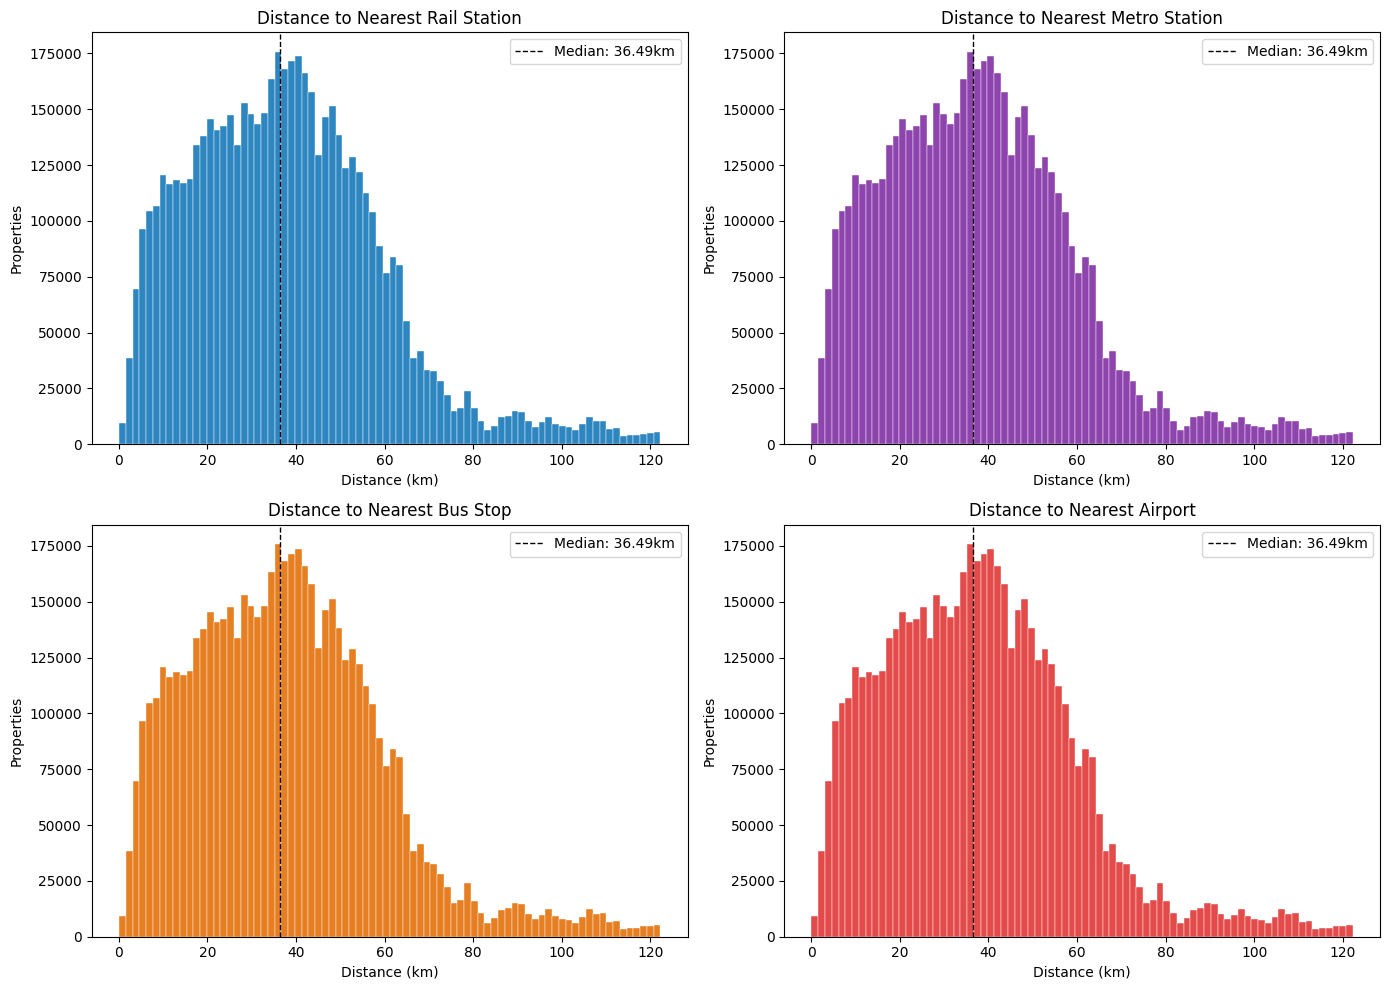

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color, title in [
    (axes[0][0], "dist_rail_km",    "#2E86C1", "Distance to Nearest Rail Station"),
    (axes[0][1], "dist_metro_km",   "#8E44AD", "Distance to Nearest Metro Station"),
    (axes[1][0], "dist_bus_km",     "#E67E22", "Distance to Nearest Bus Stop"),
    (axes[1][1], "dist_airport_km", "#E24B4A", "Distance to Nearest Airport"),
]:
    ax.hist(data, bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Properties")
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1, label=f"Median: {data.median():.2f}km")
    ax.legend()

plt.tight_layout()
plt.show()

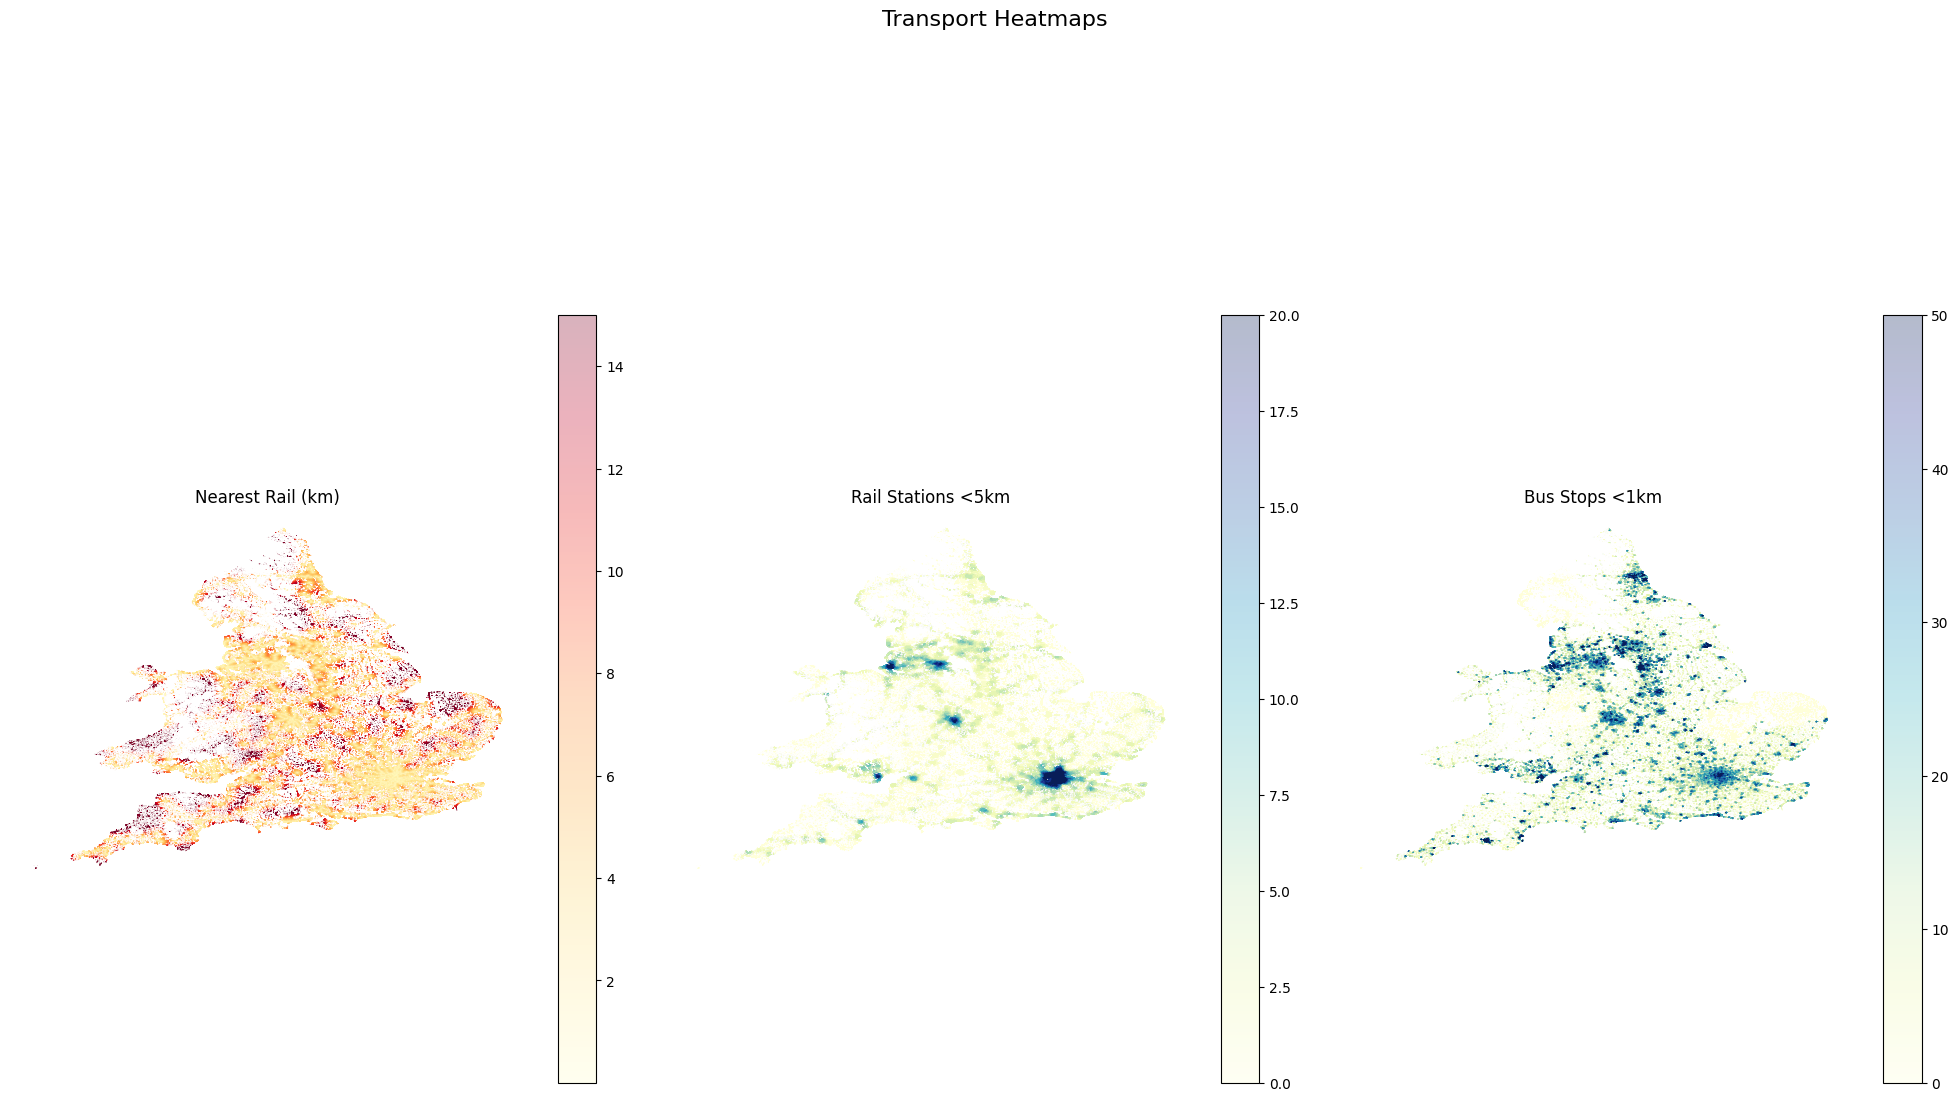

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 16), sharey=True)

lat = df_stations["exact_lat"].fillna(df_stations["LAT"])
lon = df_stations["exact_lon"].fillna(df_stations["LONG"])
mask = lat.notna() & lon.notna()

for ax, col, title, cmap, cap in [
    (axes[0], "dist_rail_km",    "Nearest Rail (km)",    "YlOrRd", 15),
    (axes[1], "rail_within_5km", "Rail Stations <5km",   "YlGnBu", 20),
    (axes[2], "bus_within_1km",  "Bus Stops <1km",       "YlGnBu", 50),
]:
    vals = df_stations.loc[mask, col].clip(upper=cap)
    sc = ax.scatter(
        lon[mask], lat[mask],
        c=vals, cmap=cmap,
        s=0.1, alpha=0.3, linewidths=0
    )
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(sc, ax=ax, shrink=0.5)

fig.suptitle("Transport Heatmaps", fontsize=16, y=0.92)
plt.tight_layout()
plt.show()

In [ ]:
print(df_stations["dist_bus_km"].describe())
print(df_stations[["price", "dist_bus_km", "bus_within_1km"]].corr()["price"]) # prob should drop bus, low correlation 

count    5.867053e+06
mean     9.659581e-01
std      4.242657e+00
min      2.987866e-04
25%      9.067877e-02
50%      1.457247e-01
75%      2.305623e-01
max      5.736105e+01
Name: dist_bus_km, dtype: float64
price             1.000000
dist_bus_km      -0.007212
bus_within_1km   -0.011699
Name: price, dtype: float64


: 

## Coastline Distance

In [2]:
df_coast = pd.read_parquet("Outputs/lr_epc_coast.parquet")

col = "dist_coast_km"
print(f"Coastline distance (km):")
print(f"  Mean:   {df_coast[col].mean():.2f}")
print(f"  Median: {df_coast[col].median():.2f}")
print(f"  Max:    {df_coast[col].max():.2f}")
print(f"  < 5km:  {(df_coast[col] < 5).sum():,} ({(df_coast[col] < 5).mean()*100:.1f}%)")
print(f"  < 20km: {(df_coast[col] < 20).sum():,} ({(df_coast[col] < 20).mean()*100:.1f}%)")

Coastline distance (km):
  Mean:   21.14
  Median: 12.80
  Max:    90.67
  < 5km:  2,037,722 (34.6%)
  < 20km: 3,494,370 (59.3%)


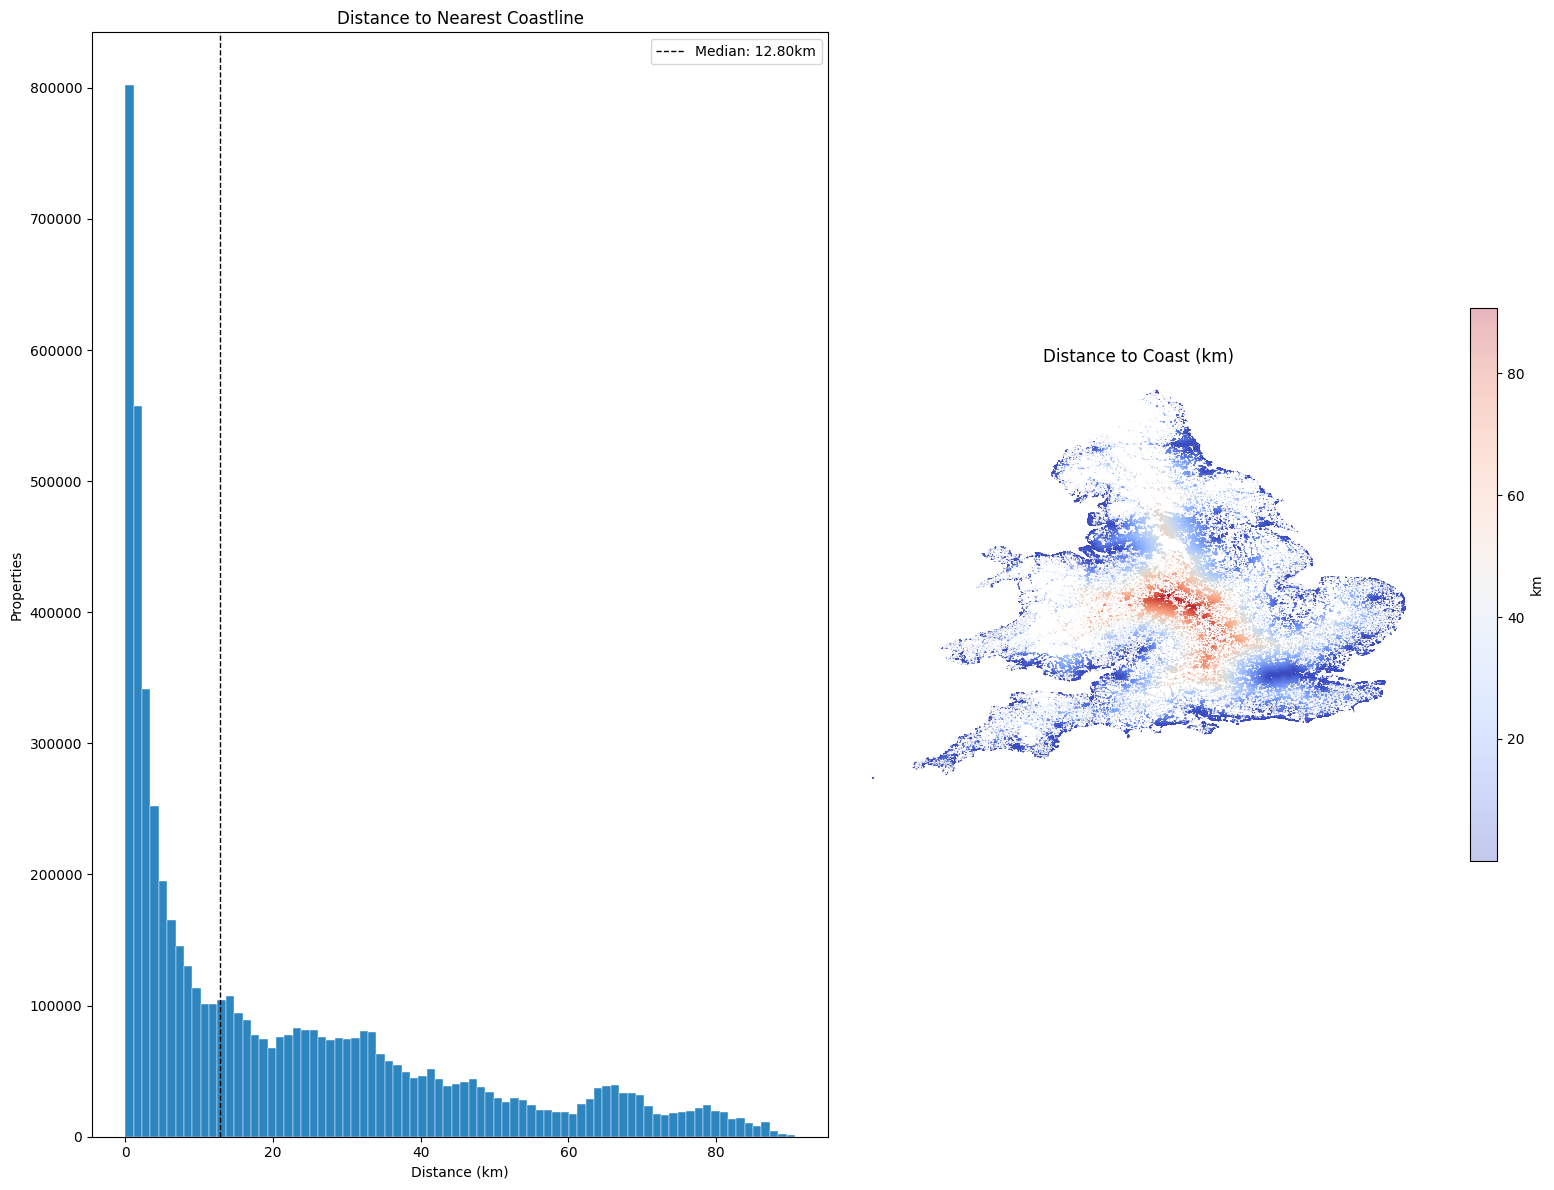

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# Histogram
data = df_coast[col].dropna()
axes[0].hist(data, bins=80, color="#2E86C1", edgecolor="white", linewidth=0.3)
axes[0].set_title("Distance to Nearest Coastline", fontsize=12)
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Properties")
axes[0].axvline(data.median(), color="black", linestyle="--", linewidth=1, label=f"Median: {data.median():.2f}km")
axes[0].legend()

# Heatmap
lat = df_coast["exact_lat"].fillna(df_coast["LAT"])
lon = df_coast["exact_lon"].fillna(df_coast["LONG"])
mask = lat.notna() & lon.notna()
vals = df_coast.loc[mask, col].clip(upper=100)
sc = axes[1].scatter(
    lon[mask], lat[mask],
    c=vals, cmap="coolwarm",
    s=0.1, alpha=0.3, linewidths=0
)
axes[1].set_title("Distance to Coast (km)", fontsize=12)
axes[1].set_aspect("equal")
axes[1].axis("off")
plt.colorbar(sc, ax=axes[1], shrink=0.5, label="km")

plt.tight_layout()
plt.savefig("coast_distance.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
print(df_coast[["price", "dist_coast_km"]].corr()["price"])

price            1.000000
dist_coast_km   -0.022777
Name: price, dtype: float64


In [6]:
df = pd.read_parquet("Outputs/lr_epc_towns.parquet")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

Rows: 5,890,089
Columns: 53
['transaction_id', 'price', 'date', 'postcode_x', 'property_type_x', 'new_build', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'postcode_clean', 'address_key', 'address1', 'postcode_y', 'uprn', 'total_floor_area', 'lodgement_date', 'current_energy_efficiency', 'current_energy_rating', 'number_habitable_rooms', 'tenure', 'property_type_y', 'transaction_type', 'construction_age_band', 'built_form', 'main_fuel', 'mains_gas_flag', 'postcode_merge', 'PCDS', 'LAT', 'LONG', 'exact_lat', 'exact_lon', 'has_exact_coords', 'dist_primary_km', 'dist_secondary_km', 'dist_rail_km', 'rail_within_1km', 'rail_within_5km', 'dist_metro_km', 'metro_within_1km', 'dist_bus_km', 'bus_within_1km', 'dist_airport_km', 'dist_coast_km', 'dist_town_km', 'nearest_town']
transaction_id                          str
price                                 int64
date                         datetime64[us]
postcode_x            